# Ejemplo práctico durante la clase (17 feb)

In [66]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a dataset
# Let´s build the values lists
value_n_list = ['Andrew', 'Phillip', 'John',"Rose","Lau", "Maye", "Mara", "Sandra","Jairo", "Marcela"]
print(value_n_list)

value_w_list = [50,         78,      91.5, 47, 70, 55, 60, 45, 67,87] # [kg]
value_h_list = [1.76,      1.87,     1.69, 1.80, 1.70, 1.68, 1.67, 1.57, 1.87, 1.65] # [m]
# value_bmi_list will be calculated: bmi = w/(h^2)
#value_bmi_list = [25,25,25] # init values [kg/m2]

# Let´s use a dictionary ({key:value})
# with the format {"str":list}
data_dict = {"name":value_n_list,
             "weight":value_w_list,
             "height":value_h_list} #,
              #"BMI":value_bmi_list}

print(data_dict)

# Turn a dictionary into a dataframe
df = pd.DataFrame(data_dict)

print(df)
# Call a variable
df

['Andrew', 'Phillip', 'John', 'Rose', 'Lau', 'Maye', 'Mara', 'Sandra', 'Jairo', 'Marcela']
{'name': ['Andrew', 'Phillip', 'John', 'Rose', 'Lau', 'Maye', 'Mara', 'Sandra', 'Jairo', 'Marcela'], 'weight': [50, 78, 91.5, 47, 70, 55, 60, 45, 67, 87], 'height': [1.76, 1.87, 1.69, 1.8, 1.7, 1.68, 1.67, 1.57, 1.87, 1.65]}
      name  weight  height
0   Andrew    50.0    1.76
1  Phillip    78.0    1.87
2     John    91.5    1.69
3     Rose    47.0    1.80
4      Lau    70.0    1.70
5     Maye    55.0    1.68
6     Mara    60.0    1.67
7   Sandra    45.0    1.57
8    Jairo    67.0    1.87
9  Marcela    87.0    1.65


,name,weight,height
0,Andrew,50.0,1.76
1,Phillip,78.0,1.87
2,John,91.5,1.69
3,Rose,47.0,1.80
4,Lau,70.0,1.70
5,Maye,55.0,1.68
6,Mara,60.0,1.67
7,Sandra,45.0,1.57
8,Jairo,67.0,1.87
9,Marcela,87.0,1.65


In [67]:
df

,name,weight,height
0,Andrew,50.0,1.76
1,Phillip,78.0,1.87
2,John,91.5,1.69
3,Rose,47.0,1.80
4,Lau,70.0,1.70
5,Maye,55.0,1.68
6,Mara,60.0,1.67
7,Sandra,45.0,1.57
8,Jairo,67.0,1.87
9,Marcela,87.0,1.65


In [68]:
# prompt: Con DataFrame df: Para agregar otra columna

#Si uno hace una operación directamente en una columna, esta operación se va a realizar en todo
#Aqui voy a crear una nueva columna que se llama bmi teniendo encuenta los valores de las columnas weight y heigh

df['bmi'] = df['weight'] / (df['height'] ** 2)
df
#entre 18 y 25 es normal el imc normal de lo contrario fuera del rango normal



,name,weight,height,bmi
0,Andrew,50.0,1.76,16.141529
1,Phillip,78.0,1.87,22.305471
2,John,91.5,1.69,32.036693
3,Rose,47.0,1.80,14.506173
4,Lau,70.0,1.70,24.221453
5,Maye,55.0,1.68,19.486961
6,Mara,60.0,1.67,21.513859
7,Sandra,45.0,1.57,18.256319
8,Jairo,67.0,1.87,19.159827
9,Marcela,87.0,1.65,31.955923


In [69]:
# Define a function to determine health condition
def determine_health_condition(bmi):
    if 18.0 <= bmi <= 25.0:
        return 'peso normal'
    if bmi<18.0:
     return "bajo peso"
    if bmi>25.0:
      return "sobrepeso"

# Aplicar la función a la columna
df["health_condition"] = df["bmi"].apply(determine_health_condition)
df

,name,weight,height,bmi,health_condition
0,Andrew,50.0,1.76,16.141529,bajo peso
1,Phillip,78.0,1.87,22.305471,peso normal
2,John,91.5,1.69,32.036693,sobrepeso
3,Rose,47.0,1.80,14.506173,bajo peso
4,Lau,70.0,1.70,24.221453,peso normal
5,Maye,55.0,1.68,19.486961,peso normal
6,Mara,60.0,1.67,21.513859,peso normal
7,Sandra,45.0,1.57,18.256319,peso normal
8,Jairo,67.0,1.87,19.159827,peso normal
9,Marcela,87.0,1.65,31.955923,sobrepeso


Ahora vamos a aumentar hasta 1000 registros

In [70]:
# Calculate how many new records are needed to reach 1000
num_current_records = len(df)
num_records_to_generate = 1000 - num_current_records

if num_records_to_generate > 0:
    # Define the list of Spanish names (if not already defined or to ensure it's available)
    spanish_names = ['Maria', 'Jose', 'Ana', 'Carlos', 'Sofia', 'David', 'Laura', 'Pedro', 'Isabel', 'Miguel', 'Elena', 'Pablo', 'Carmen', 'Javier', 'Luisa', 'Antonio', 'Cristina', 'Manuel', 'Sara', 'Fernando']

    # Generate new records
    new_data = {
        'name': np.random.choice(spanish_names, size=num_records_to_generate),
        'weight': np.random.uniform(40, 100, num_records_to_generate), # Random weights between 40 and 100 kg
        'height': np.random.uniform(1.50, 1.90, num_records_to_generate) # Random heights between 1.50 and 1.90 meters
    }

    new_df_to_add = pd.DataFrame(new_data)

    # Calculate BMI for the new data
    new_df_to_add['bmi'] = new_df_to_add['weight'] / (new_df_to_add['height'] ** 2)

    # Define the health condition function
    def determine_health_condition(bmi):
        if 18.0 <= bmi <= 25.0:
            return 'peso normal'
        elif bmi < 18.0:
            return 'bajo peso'
        else:
            return 'sobrepeso'

    # Apply the function to create the 'health_condition4' column for new data
    new_df_to_add['health_condition4'] = new_df_to_add['bmi'].apply(determine_health_condition)

    # Append the new DataFrame to the existing df
    df = pd.concat([df, new_df_to_add], ignore_index=True)
    print(f"Successfully added {num_records_to_generate} records.")
    print(f"New DataFrame shape: {df.shape}")
    display(df.head())
    display(df.tail())
else:
    print(f"DataFrame already has {num_current_records} records. No new records were added.")
    display(df.head())
    display(df.tail())

Successfully added 990 records.
New DataFrame shape: (1000, 6)


,name,weight,height,bmi,health_condition,health_condition4
0,Andrew,50.0,1.76,16.141529,bajo peso,NaN
1,Phillip,78.0,1.87,22.305471,peso normal,NaN
2,John,91.5,1.69,32.036693,sobrepeso,NaN
3,Rose,47.0,1.80,14.506173,bajo peso,NaN
4,Lau,70.0,1.70,24.221453,peso normal,NaN


,name,weight,height,bmi,health_condition,health_condition4
995,Javier,66.984661,1.676942,23.819871,NaN,peso normal
996,Fernando,92.083597,1.822987,27.708636,NaN,sobrepeso
997,Carmen,96.019300,1.527686,41.142471,NaN,sobrepeso
998,Luisa,57.185515,1.856594,16.590219,NaN,bajo peso
999,Manuel,80.302051,1.888232,22.522460,NaN,peso normal


In [71]:
df.describe()

,weight,height,bmi
count,1000.000000,1000.000000,1000.000000
mean,69.783869,1.705541,24.355685
std,17.027284,0.114600,6.971295
min,40.211525,1.500408,11.378639
25%,55.562549,1.608227,18.946110
50%,69.137118,1.703991,23.851164
75%,84.691470,1.802803,28.928981
max,99.951599,1.899608,43.968240


## Making some transformations on the df

In [72]:
# z = x / y*y
df["BMI"] =  df["weight"] / df["height"]**2
df

,name,weight,height,bmi,health_condition,health_condition4,BMI
0,Andrew,50.000000,1.760000,16.141529,bajo peso,NaN,16.141529
1,Phillip,78.000000,1.870000,22.305471,peso normal,NaN,22.305471
2,John,91.500000,1.690000,32.036693,sobrepeso,NaN,32.036693
3,Rose,47.000000,1.800000,14.506173,bajo peso,NaN,14.506173
4,Lau,70.000000,1.700000,24.221453,peso normal,NaN,24.221453
...,...,...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,NaN,peso normal,23.819871
996,Fernando,92.083597,1.822987,27.708636,NaN,sobrepeso,27.708636
997,Carmen,96.019300,1.527686,41.142471,NaN,sobrepeso,41.142471
998,Luisa,57.185515,1.856594,16.590219,NaN,bajo peso,16.590219


In [73]:
columns_to_drop_if_exist = ['BMI', 'health_condition', 'health_condition4', 'health_condition6', 'health_status']

# Filter out columns that don't exist in the DataFrame to prevent errors
existing_columns_to_drop = [col for col in columns_to_drop_if_exist if col in df.columns]

if existing_columns_to_drop:
    df.drop(columns=existing_columns_to_drop, inplace=True)
    print(f"Dropped redundant/problematic columns: {existing_columns_to_drop}")
else:
    print("No redundant/problematic health condition columns found to drop.")

# Define the function to determine health condition (ensuring it's available in this scope)
def determine_health_condition(bmi):
    if 18.0 <= bmi <= 25.0:
        return 'peso normal'
    elif bmi < 18.0:
        return 'bajo peso'
    else:
        return 'sobrepeso'

# Re-apply the function to create a clean 'health_status' column
df['health_status'] = df['bmi'].apply(determine_health_condition)

print("\nDataFrame head after cleaning and re-calculating health_status:")
display(df.head())

print("\nDataFrame tail after cleaning and re-calculating health_status:")
display(df.tail())

Dropped redundant/problematic columns: ['BMI', 'health_condition', 'health_condition4']

DataFrame head after cleaning and re-calculating health_status:


,name,weight,height,bmi,health_status
0,Andrew,50.0,1.76,16.141529,bajo peso
1,Phillip,78.0,1.87,22.305471,peso normal
2,John,91.5,1.69,32.036693,sobrepeso
3,Rose,47.0,1.80,14.506173,bajo peso
4,Lau,70.0,1.70,24.221453,peso normal



DataFrame tail after cleaning and re-calculating health_status:


,name,weight,height,bmi,health_status
995,Javier,66.984661,1.676942,23.819871,peso normal
996,Fernando,92.083597,1.822987,27.708636,sobrepeso
997,Carmen,96.019300,1.527686,41.142471,sobrepeso
998,Luisa,57.185515,1.856594,16.590219,bajo peso
999,Manuel,80.302051,1.888232,22.522460,peso normal


De acuerdo a los resultados puede conlcuir que:

-El valor max es:
-

In [74]:
df["bmi"].dtype

dtype('float64')

In [75]:
# TO-DO: create another column with integers and turn it to float, such as:
df["bmi"] = df["bmi"].astype(float)

In [76]:
df["name"].dtype
# Homework: how to verify that a column contains string

dtype('O')

In [77]:
df

,name,weight,height,bmi,health_status
0,Andrew,50.000000,1.760000,16.141529,bajo peso
1,Phillip,78.000000,1.870000,22.305471,peso normal
2,John,91.500000,1.690000,32.036693,sobrepeso
3,Rose,47.000000,1.800000,14.506173,bajo peso
4,Lau,70.000000,1.700000,24.221453,peso normal
...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,peso normal
996,Fernando,92.083597,1.822987,27.708636,sobrepeso
997,Carmen,96.019300,1.527686,41.142471,sobrepeso
998,Luisa,57.185515,1.856594,16.590219,bajo peso


# Task:

1. Remove duplicate columns

2. Classify into at least 3 categories (3, 4, 5)

3. Add at least 7 more records (manually). Optional: automatically create 100 records

## Init steps towards EDA (Exploratory Data Analisys):
 Homework: perform a full EDA with your own invented dataset with at least 10 rows

### TO-DO: please analyze the results (univariate: describe() / multivariate: correlation matrix: search about it)



In [78]:
# Descriptive stats
df_stats = df.describe()
df_stats

,weight,height,bmi
count,1000.000000,1000.000000,1000.000000
mean,69.783869,1.705541,24.355685
std,17.027284,0.114600,6.971295
min,40.211525,1.500408,11.378639
25%,55.562549,1.608227,18.946110
50%,69.137118,1.703991,23.851164
75%,84.691470,1.802803,28.928981
max,99.951599,1.899608,43.968240


In [79]:
#df["health_condition"] = 'within the normal range' if 18.0<=df['BMI']<=25.0 else 'out of the normal range'
#df

# Prompt used in chat GPT (by OpenAI) / Gemini (by Google) / Bing (Copilot by Microsoft) to solve the above error:

You are a python expert, please help with the error I will show later that is appearing when I run this code in Google collab: "df["health_condition"] = 'within the normal range' if 18.0<=df['BMI']<=25.0 else 'out of the normal range'".  

The error is:

---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
<ipython-input-16-4e9a74b99b6c> in <cell line: 1>()
----> 1 df["health_condition"] = 'within the normal range' if 18.0<=df['BMI']<=25.0 else 'out of the normal range'
      2 df

/usr/local/lib/python3.10/dist-packages/pandas/core/generic.py in __nonzero__(self)
   1525     @final
   1526     def __nonzero__(self) -> NoReturn:
-> 1527         raise ValueError(
   1528             f"The truth value of a {type(self).__name__} is ambiguous. "
   1529             "Use a.empty, a.bool(), a.item(), a.any() or a.all()."

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().




In [80]:
df

,name,weight,height,bmi,health_status
0,Andrew,50.000000,1.760000,16.141529,bajo peso
1,Phillip,78.000000,1.870000,22.305471,peso normal
2,John,91.500000,1.690000,32.036693,sobrepeso
3,Rose,47.000000,1.800000,14.506173,bajo peso
4,Lau,70.000000,1.700000,24.221453,peso normal
...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,peso normal
996,Fernando,92.083597,1.822987,27.708636,sobrepeso
997,Carmen,96.019300,1.527686,41.142471,sobrepeso
998,Luisa,57.185515,1.856594,16.590219,bajo peso


In [81]:
print(df)

         name     weight    height        bmi health_status
0      Andrew  50.000000  1.760000  16.141529     bajo peso
1     Phillip  78.000000  1.870000  22.305471   peso normal
2        John  91.500000  1.690000  32.036693     sobrepeso
3        Rose  47.000000  1.800000  14.506173     bajo peso
4         Lau  70.000000  1.700000  24.221453   peso normal
..        ...        ...       ...        ...           ...
995    Javier  66.984661  1.676942  23.819871   peso normal
996  Fernando  92.083597  1.822987  27.708636     sobrepeso
997    Carmen  96.019300  1.527686  41.142471     sobrepeso
998     Luisa  57.185515  1.856594  16.590219     bajo peso
999    Manuel  80.302051  1.888232  22.522460   peso normal

[1000 rows x 5 columns]


In [82]:
df_stats

,weight,height,bmi
count,1000.000000,1000.000000,1000.000000
mean,69.783869,1.705541,24.355685
std,17.027284,0.114600,6.971295
min,40.211525,1.500408,11.378639
25%,55.562549,1.608227,18.946110
50%,69.137118,1.703991,23.851164
75%,84.691470,1.802803,28.928981
max,99.951599,1.899608,43.968240


In [83]:
print(df_stats)

            weight       height          bmi
count  1000.000000  1000.000000  1000.000000
mean     69.783869     1.705541    24.355685
std      17.027284     0.114600     6.971295
min      40.211525     1.500408    11.378639
25%      55.562549     1.608227    18.946110
50%      69.137118     1.703991    23.851164
75%      84.691470     1.802803    28.928981
max      99.951599     1.899608    43.968240


In [84]:
df["health_status"] = np.where(  (df['bmi'] >= 18.0) & (df['bmi'] <= 25.0) , 'within the normal range', 'out of the normal range' )
df


,name,weight,height,bmi,health_status
0,Andrew,50.000000,1.760000,16.141529,out of the normal range
1,Phillip,78.000000,1.870000,22.305471,within the normal range
2,John,91.500000,1.690000,32.036693,out of the normal range
3,Rose,47.000000,1.800000,14.506173,out of the normal range
4,Lau,70.000000,1.700000,24.221453,within the normal range
...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,within the normal range
996,Fernando,92.083597,1.822987,27.708636,out of the normal range
997,Carmen,96.019300,1.527686,41.142471,out of the normal range
998,Luisa,57.185515,1.856594,16.590219,out of the normal range


In [85]:
# Define a function to determine health condition
def determine_health_condition(bmi):
    if 18.0 <= bmi <= 25.0:
        return 'within the normal range'
    else:
        return 'out of the normal range'

# Apply the function to create the new column
df["health_status"] = df["bmi"].apply(determine_health_condition)


print(df)
df


         name     weight    height        bmi            health_status
0      Andrew  50.000000  1.760000  16.141529  out of the normal range
1     Phillip  78.000000  1.870000  22.305471  within the normal range
2        John  91.500000  1.690000  32.036693  out of the normal range
3        Rose  47.000000  1.800000  14.506173  out of the normal range
4         Lau  70.000000  1.700000  24.221453  within the normal range
..        ...        ...       ...        ...                      ...
995    Javier  66.984661  1.676942  23.819871  within the normal range
996  Fernando  92.083597  1.822987  27.708636  out of the normal range
997    Carmen  96.019300  1.527686  41.142471  out of the normal range
998     Luisa  57.185515  1.856594  16.590219  out of the normal range
999    Manuel  80.302051  1.888232  22.522460  within the normal range

[1000 rows x 5 columns]


,name,weight,height,bmi,health_status
0,Andrew,50.000000,1.760000,16.141529,out of the normal range
1,Phillip,78.000000,1.870000,22.305471,within the normal range
2,John,91.500000,1.690000,32.036693,out of the normal range
3,Rose,47.000000,1.800000,14.506173,out of the normal range
4,Lau,70.000000,1.700000,24.221453,within the normal range
...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,within the normal range
996,Fernando,92.083597,1.822987,27.708636,out of the normal range
997,Carmen,96.019300,1.527686,41.142471,out of the normal range
998,Luisa,57.185515,1.856594,16.590219,out of the normal range


In [86]:
print(df)
df

         name     weight    height        bmi            health_status
0      Andrew  50.000000  1.760000  16.141529  out of the normal range
1     Phillip  78.000000  1.870000  22.305471  within the normal range
2        John  91.500000  1.690000  32.036693  out of the normal range
3        Rose  47.000000  1.800000  14.506173  out of the normal range
4         Lau  70.000000  1.700000  24.221453  within the normal range
..        ...        ...       ...        ...                      ...
995    Javier  66.984661  1.676942  23.819871  within the normal range
996  Fernando  92.083597  1.822987  27.708636  out of the normal range
997    Carmen  96.019300  1.527686  41.142471  out of the normal range
998     Luisa  57.185515  1.856594  16.590219  out of the normal range
999    Manuel  80.302051  1.888232  22.522460  within the normal range

[1000 rows x 5 columns]


,name,weight,height,bmi,health_status
0,Andrew,50.000000,1.760000,16.141529,out of the normal range
1,Phillip,78.000000,1.870000,22.305471,within the normal range
2,John,91.500000,1.690000,32.036693,out of the normal range
3,Rose,47.000000,1.800000,14.506173,out of the normal range
4,Lau,70.000000,1.700000,24.221453,within the normal range
...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,within the normal range
996,Fernando,92.083597,1.822987,27.708636,out of the normal range
997,Carmen,96.019300,1.527686,41.142471,out of the normal range
998,Luisa,57.185515,1.856594,16.590219,out of the normal range


se analizó si esta fuera del rango por debajo o por encima, no solo si esta dentro del rango

In [88]:
# Define a function to determine health condition
def determine_health_condition7(bmi):
    """
    if 18.0 <= bmi <= 25.0:
        return 'within the normal range'
    else:
        return 'out of the normal range'
    """
    return 'within the normal range' if 18.0 <= bmi <= 25.0 else 'out of the normal range'

# Apply the function to create the new column
df["health_status"] = df["bmi"].apply(determine_health_condition7)
df

,name,weight,height,bmi,health_status
0,Andrew,50.000000,1.760000,16.141529,out of the normal range
1,Phillip,78.000000,1.870000,22.305471,within the normal range
2,John,91.500000,1.690000,32.036693,out of the normal range
3,Rose,47.000000,1.800000,14.506173,out of the normal range
4,Lau,70.000000,1.700000,24.221453,within the normal range
...,...,...,...,...,...
995,Javier,66.984661,1.676942,23.819871,within the normal range
996,Fernando,92.083597,1.822987,27.708636,out of the normal range
997,Carmen,96.019300,1.527686,41.142471,out of the normal range
998,Luisa,57.185515,1.856594,16.590219,out of the normal range


Matriz de Correlación para combined_df:
          weight    height       bmi
weight  1.000000  0.022879  0.848403
height  0.022879  1.000000 -0.494691
bmi     0.848403 -0.494691  1.000000


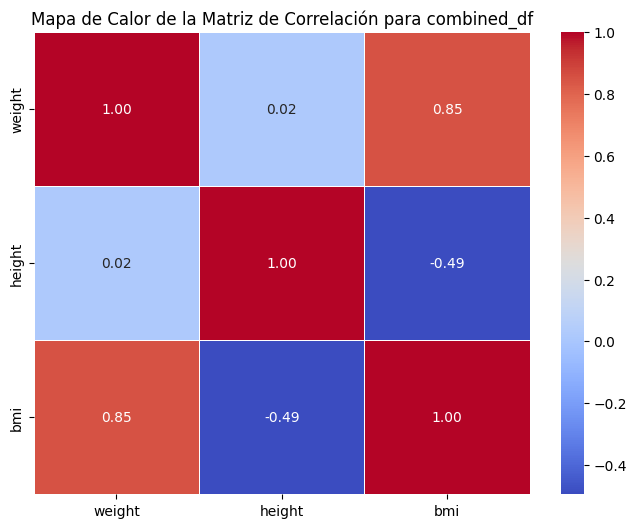

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the numerical columns
correlation_matrix_combined = combined_df[['weight', 'height', 'bmi']].corr()

print("Matriz de Correlación para combined_df:")
print(correlation_matrix_combined)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_combined, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación para combined_df')
plt.show()

#### Please remove the unnecessary columns and search how to upload/download the df as .csv and .json and .xlsx




# Correlation matrix:

ChatGPT prompt used:

"you´re a python expert, please give code to get the correlation matrix of a dataframe with a simple example and calculus explanation"

In [90]:
import pandas as pd

# Create a sample DataFrame
data = {
    'A': [1, 2, 3, 4],
    'B': [4, 3, 2, 1],
    'C': [2, 4, 6, 8],
}

df = pd.DataFrame(data)

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
     A    B    C
A  1.0 -1.0  1.0
B -1.0  1.0 -1.0
C  1.0 -1.0  1.0


## Explicación Matemática de la Matriz de Correlación

La matriz de correlación es una tabla que muestra los coeficientes de correlación entre diferentes variables. Cada elemento $r_{ij}$ de la matriz representa el coeficiente de correlación de Pearson entre la variable $X_i$ y la variable $X_j$. El coeficiente de correlación de Pearson mide la fuerza y la dirección de una relación lineal entre dos variables.

### Coeficiente de Correlación de Pearson ($r$)

Para dos variables $X$ y $Y$, el coeficiente de correlación de Pearson se calcula de la siguiente manera:

$$ r_{XY} = \frac{\sum_{k=1}^{n}(X_k - \bar{X})(Y_k - \bar{Y})}{\sqrt{\sum_{k=1}^{n}(X_k - \bar{X})^2 \sum_{k=1}^{n}(Y_k - \bar{Y})^2}} $$

Donde:
- $n$ es el número de observaciones (o pares de datos).
- $X_k$ y $Y_k$ son los valores individuales de las variables $X$ y $Y$ para la $k$-ésima observación.
- $\bar{X}$ es la media (promedio) de la variable $X$.
- $\bar{Y}$ es la media (promedio) de la variable $Y$.

También se puede expresar en términos de la covarianza y las desviaciones estándar:

$$ r_{XY} = \frac{\text{Cov}(X, Y)}{S_X S_Y} $$

Donde:
- $\text{Cov}(X, Y)$ es la covarianza entre $X$ y $Y$:  
  $\text{Cov}(X, Y) = \frac{1}{n-1}\sum_{k=1}^{n}(X_k - \bar{X})(Y_k - \bar{Y})$
- $S_X$ es la desviación estándar de $X$:
  $S_X = \sqrt{\frac{1}{n-1}\sum_{k=1}^{n}(X_k - \bar{X})^2}$
- $S_Y$ es la desviación estándar de $Y$:
  $S_Y = \sqrt{\frac{1}{n-1}\sum_{k=1}^{n}(Y_k - \bar{Y})^2}$

### La Matriz de Correlación ($R$)

Si tenemos $p$ variables ($X_1, X_2, ..., X_p$), la matriz de correlación $R$ es una matriz simétrica $p \times p$ donde el elemento en la fila $i$ y columna $j$ ($r_{ij}$) es el coeficiente de correlación de Pearson entre $X_i$ y $X_j$. La diagonal principal de la matriz ($r_{ii}$) siempre será 1, ya que la correlación de una variable consigo misma es perfecta.

$$ R = \begin{pmatrix}
1 & r_{12} & \cdots & r_{1p} \\
r_{21} & 1 & \cdots & r_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
r_{p1} & r_{p2} & \cdots & 1
\end{pmatrix} $$

Dado que $r_{ij} = r_{ji}$, la matriz es simétrica.

In [91]:
 # Simple example given by chat GPT
import pandas as pd

# Create a sample DataFrame
data = {
    'A': [1, 2, 3, 4],
    'B': [4, 3, 2, 1],
    'C': [2, 4, 6, 8],
}

df = pd.DataFrame(data)

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
     A    B    C
A  1.0 -1.0  1.0
B -1.0  1.0 -1.0
C  1.0 -1.0  1.0


# A more complete example with synthetic data given by ChatGPT

Correlation Matrix:
          A         B         C         D
A  1.000000 -0.136422  0.190840 -0.170227
B -0.136422  1.000000 -0.036632 -0.017613
C  0.190840 -0.036632  1.000000 -0.000259
D -0.170227 -0.017613 -0.000259  1.000000


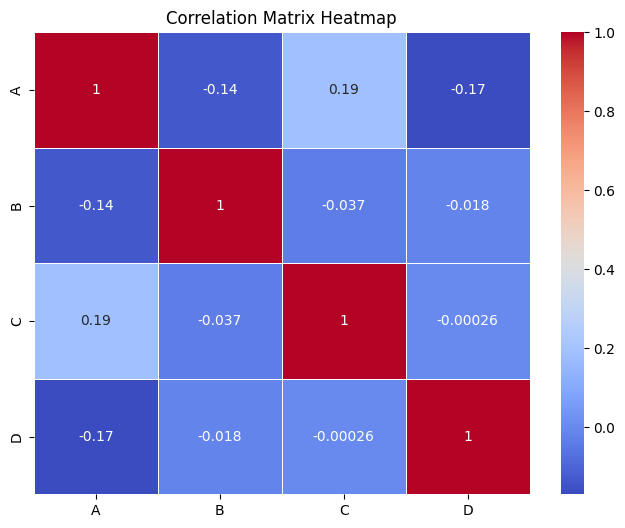

In [92]:
import pandas as pd
import seaborn as sns #sirve para hacer gráficos y visulizaciones de datos
import matplotlib.pyplot as plt #graficos


# Generate synthetic data
np.random.seed(42)  # for reproducibility

data = {
    'A': np.random.randn(100),
    'B': np.random.randn(100) * 2,
    'C': np.random.randn(100) + 1,
    'D': np.random.randn(100) - 1,
}

df = pd.DataFrame(data)

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


signo negativo: relacion inversa en la matriz

se considera fuerte despues del 50% pa arriba

formula para la correlacion, consulta

In [93]:
data

{'A': array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337,
        -0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004,
        -0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783,
        -0.56228753, -1.01283112,  0.31424733, -0.90802408, -1.4123037 ,
         1.46564877, -0.2257763 ,  0.0675282 , -1.42474819, -0.54438272,
         0.11092259, -1.15099358,  0.37569802, -0.60063869, -0.29169375,
        -0.60170661,  1.85227818, -0.01349722, -1.05771093,  0.82254491,
        -1.22084365,  0.2088636 , -1.95967012, -1.32818605,  0.19686124,
         0.73846658,  0.17136828, -0.11564828, -0.3011037 , -1.47852199,
        -0.71984421, -0.46063877,  1.05712223,  0.34361829, -1.76304016,
         0.32408397, -0.38508228, -0.676922  ,  0.61167629,  1.03099952,
         0.93128012, -0.83921752, -0.30921238,  0.33126343,  0.97554513,
        -0.47917424, -0.18565898, -1.10633497, -1.19620662,  0.81252582,
         1.35624003, -0.07201012,  1.0035329 ,

In [94]:
df

,A,B,C,D
0,0.496714,-2.830741,1.357787,-1.828995
1,-0.138264,-0.841291,1.560785,-1.560181
2,0.647689,-0.685429,2.083051,-0.252706
3,1.523030,-1.604555,2.053802,-0.389630
4,-0.234153,-0.322571,-0.377669,-1.020902
...,...,...,...,...
95,-1.463515,0.770635,0.307090,-1.469176
96,0.296120,-1.767715,1.899600,-2.713135
97,0.261055,0.307450,1.307300,0.353872
98,0.005113,0.116417,1.812862,-1.114540


# Consultar cómo es el cálculo de la matriz de correlación (PEND):

Chat GPT Prompt: "Please, give me the explanation mathematically about the way the correlation matrix computation is performed"

## Explicación Matemática de la Matriz de Correlación

La matriz de correlación es una tabla que muestra los coeficientes de correlación entre diferentes variables. Cada elemento $r_{ij}$ de la matriz representa el coeficiente de correlación de Pearson entre la variable $X_i$ y la variable $X_j$. El coeficiente de correlación de Pearson mide la fuerza y la dirección de una relación lineal entre dos variables.

### Coeficiente de Correlación de Pearson ($r$)

Para dos variables $X$ y $Y$, el coeficiente de correlación de Pearson se calcula de la siguiente manera:

$$ r_{XY} = \frac{\sum_{k=1}^{n}(X_k - \bar{X})(Y_k - \bar{Y})}{\sqrt{\sum_{k=1}^{n}(X_k - \bar{X})^2 \sum_{k=1}^{n}(Y_k - \bar{Y})^2}} $$

Donde:
- $n$ es el número de observaciones (o pares de datos).
- $X_k$ y $Y_k$ son los valores individuales de las variables $X$ y $Y$ para la $k$-ésima observación.
- $\bar{X}$ es la media (promedio) de la variable $X$.
- $\bar{Y}$ es la media (promedio) de la variable $Y$.

También se puede expresar en términos de la covarianza y las desviaciones estándar:

$$ r_{XY} = \frac{\text{Cov}(X, Y)}{S_X S_Y} $$

Donde:
- $\text{Cov}(X, Y)$ es la covarianza entre $X$ y $Y$:  
  $\text{Cov}(X, Y) = \frac{1}{n-1}\sum_{k=1}^{n}(X_k - \bar{X})(Y_k - \bar{Y})$
- $S_X$ es la desviación estándar de $X$:
  $S_X = \sqrt{\frac{1}{n-1}\sum_{k=1}^{n}(X_k - \bar{X})^2}$
- $S_Y$ es la desviación estándar de $Y$:
  $S_Y = \sqrt{\frac{1}{n-1}\sum_{k=1}^{n}(Y_k - \bar{Y})^2}$

### La Matriz de Correlación ($R$)

Si tenemos $p$ variables ($X_1, X_2, ..., X_p$), la matriz de correlación $R$ es una matriz simétrica $p \times p$ donde el elemento en la fila $i$ y columna $j$ ($r_{ij}$) es el coeficiente de correlación de Pearson entre $X_i$ y $X_j$. La diagonal principal de la matriz ($r_{ii}$) siempre será 1, ya que la correlación de una variable consigo misma es perfecta.

$$ R = \begin{pmatrix}
1 & r_{12} & \cdots & r_{1p} \\
r_{21} & 1 & \cdots & r_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
r_{p1} & r_{p2} & \cdots & 1
\end{pmatrix} $$

Dado que $r_{ij} = r_{ji}$, la matriz es simétrica.

Resultado:

Incluir formulas como si estuvieran escritas en un tablero

```
# E`sto tiene formato de código`
```



zcvSFvs



# Tarea: consultar qué es y cómo funciona la matriz de confusión (clasificación)

cDSVsd

# Consultar las métricas de desempeño para regresión y clasificación